# Workshop -1 Adding Sunglasses to Your Passport Photo Using OpenCV
## Name: Sivaprasath R
## Reg No: 212224243007

Face shape: (516, 402, 3)


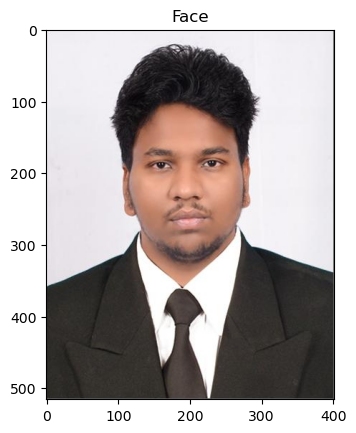

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Load face image
faceImage = cv2.imread("My photo.jpeg")
plt.imshow(faceImage[:,:,::-1]); plt.title("Face")
print("Face shape:", faceImage.shape)

Glass shape: (273, 627, 3)


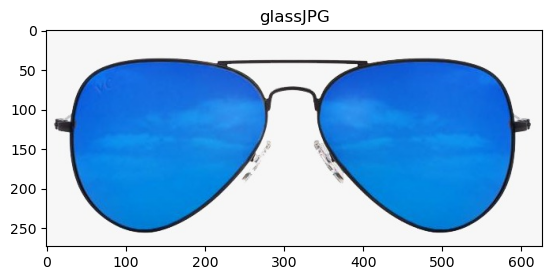

In [2]:
glassJPG = cv2.imread("sunglass.jpeg")
plt.imshow(glassJPG[:,:,::-1]); plt.title("glassJPG")
print("Glass shape:", glassJPG.shape)

Text(0.5, 1.0, 'Sunglass Color channels')

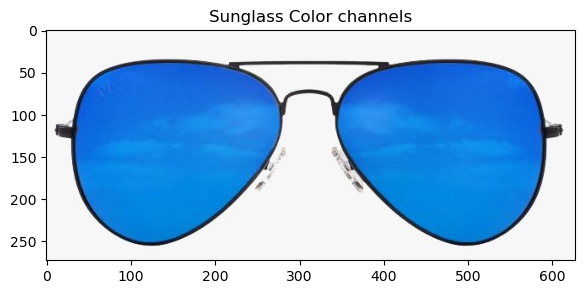

In [3]:
glassBGR = glassJPG[:,:,0:3]
glassGray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)
_, glassMask1 = cv2.threshold(glassGray, 240, 255, cv2.THRESH_BINARY_INV)  # detect non-white

plt.figure(figsize=[15,15])
#Show sunglasses color channels
plt.subplot(121)
plt.imshow(glassBGR[:,:,::-1])  # BGR → RGB
plt.title('Sunglass Color channels')

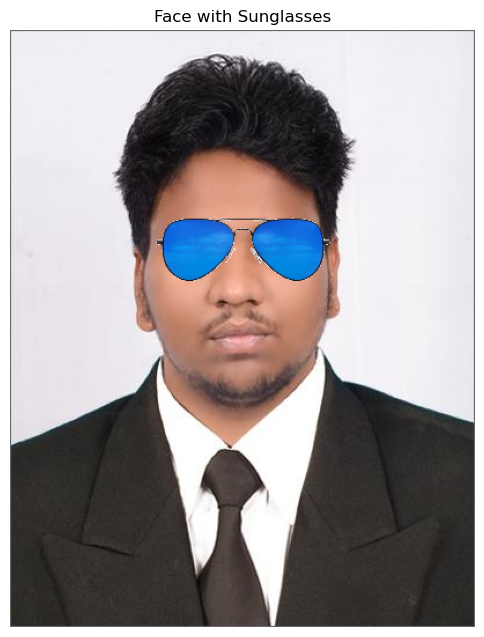

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
faceImage = cv2.imread("My photo.jpeg")
glassImage = cv2.imread("sunglass.jpeg")

# Check images
if faceImage is None or glassImage is None:
    print("Error: Image not found!")
    exit()

# Get face dimensions
face_h, face_w = faceImage.shape[:2]

# Resize sunglasses
new_w = int(face_w * 0.39)
new_h = int(new_w * glassImage.shape[0] / glassImage.shape[1])

glass_resized = cv2.resize(glassImage, (new_w, new_h))

# Create mask for sunglasses
glass_gray = cv2.cvtColor(glass_resized, cv2.COLOR_BGR2GRAY)

# Detect non-white areas
_, mask = cv2.threshold(
    glass_gray, 240, 255, cv2.THRESH_BINARY_INV
)

# Position of sunglasses
x = int(face_w * 0.31)
y = int(face_h * 0.30)

# Make sure glasses fit inside the face image
if x + new_w > face_w:
    new_w = face_w - x

if y + new_h > face_h:
    new_h = face_h - y

# Resize again if necessary
glass_resized = cv2.resize(glass_resized, (new_w, new_h))
mask = cv2.resize(mask, (new_w, new_h))

# Select face region
roi = faceImage[y:y+new_h, x:x+new_w]

# Create inverse mask
mask_inv = cv2.bitwise_not(mask)

# Remove sunglasses area from ROI
background = cv2.bitwise_and(roi, roi, mask=mask_inv)

# Extract sunglasses
foreground = cv2.bitwise_and(
    glass_resized, glass_resized, mask=mask
)

# Combine images
result = cv2.add(background, foreground)

# Put result back on face
faceImage[y:y+new_h, x:x+new_w] = result

# Display output
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB))
plt.title("Face with Sunglasses")
plt.axis("off")
plt.show()